In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd


In [3]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

Using columns: Crop = Crop, Production = Production_Tonnes


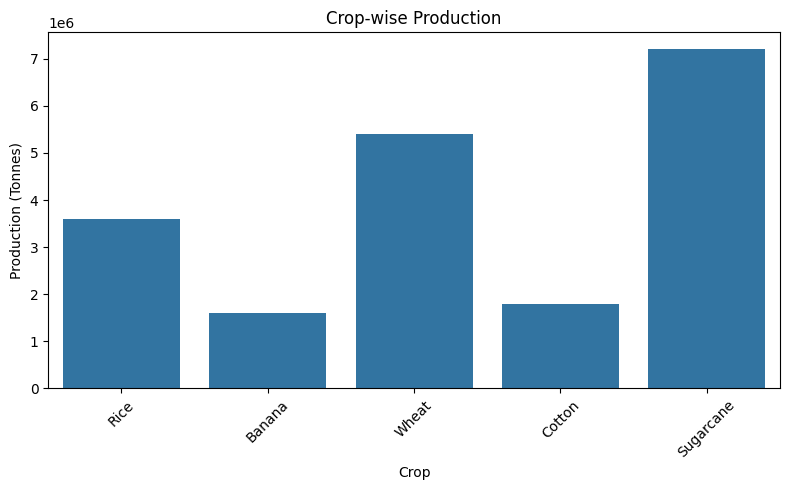

In [9]:


# Select the correct columns from the dataset
crop_col = 'Crop'
production_col = 'Production_Tonnes'

# Display which columns we are using
print(f"Using columns: Crop = {crop_col}, Production = {production_col}")

# Plot Crop vs Production
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x=crop_col, y=production_col)

plt.title('Crop-wise Production')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:

df = pd.read_csv("C:/Users/WINDOWS/Downloads/agriculture_data.csv")

# Step 2: Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# Step 3: Print all column names
print("\n🧾 Column Names in Your Dataset:")
print(df.columns.tolist())

# Step 4: Preview data
print("\n📊 Data Preview:")
print(df.head())

# Step 5: Info & Stats
print("\n🔍 Dataset Info:")
df.info()

print("\n📈 Summary Statistics:")
print(df.describe())


🧾 Column Names in Your Dataset:
['State', 'Crop', 'Year', 'Area_Hectares', 'Production_Tonnes']

📊 Data Preview:
         State       Crop  Year  Area_Hectares  Production_Tonnes
0   Tamil Nadu       Rice  2020        1200000            3600000
1       Kerala     Banana  2020         450000            1600000
2       Punjab      Wheat  2020        1800000            5400000
3      Gujarat     Cotton  2020         700000            1800000
4  Maharashtra  Sugarcane  2020         900000            7200000

🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   State              5 non-null      object
 1   Crop               5 non-null      object
 2   Year               5 non-null      int64 
 3   Area_Hectares      5 non-null      int64 
 4   Production_Tonnes  5 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 33


Using columns: Crop = Crop, Production = Production_Tonnes


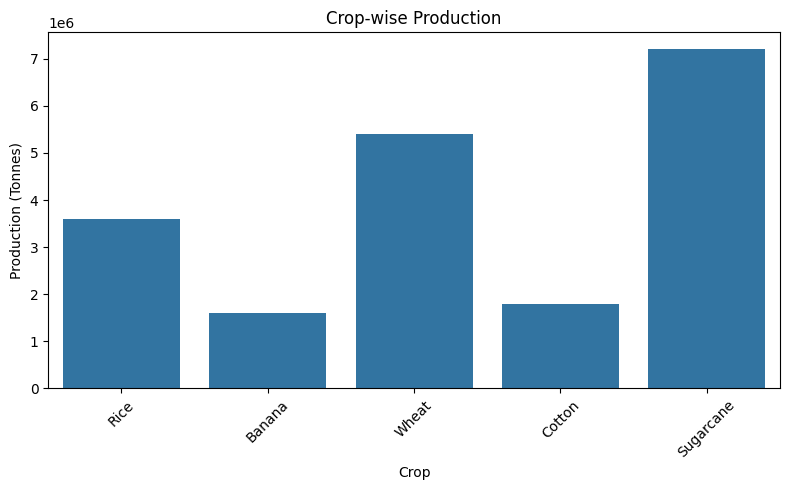

In [22]:
# Analyze Crop Production

crop_col = 'Crop'
production_col = 'Production_Tonnes'

print(f"\nUsing columns: Crop = {crop_col}, Production = {production_col}")

# Plot Crop vs Production
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x=crop_col,
    y=production_col
)

plt.title('Crop-wise Production')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [11]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
State                0
Crop                 0
Year                 0
Area_Hectares        0
Production_Tonnes    0
dtype: int64


In [12]:
# Crop-wise production analysis
crop_production = df.groupby('Crop')['Production_Tonnes'].sum().sort_values(ascending=False)

print("Total Production by Crop:")
print(crop_production)

Total Production by Crop:
Crop
Sugarcane    7200000
Wheat        5400000
Rice         3600000
Cotton       1800000
Banana       1600000
Name: Production_Tonnes, dtype: int64


In [13]:
# State-wise production analysis
state_production = df.groupby('State')['Production_Tonnes'].sum().sort_values(ascending=False)

print("Total Production by State:")
print(state_production)

Total Production by State:
State
Maharashtra    7200000
Punjab         5400000
Tamil Nadu     3600000
Gujarat        1800000
Kerala         1600000
Name: Production_Tonnes, dtype: int64


In [14]:
# Year-wise production analysis
year_production = df.groupby('Year')['Production_Tonnes'].sum()

print("Total Production by Year:")
print(year_production)


Total Production by Year:
Year
2020    19600000
Name: Production_Tonnes, dtype: int64


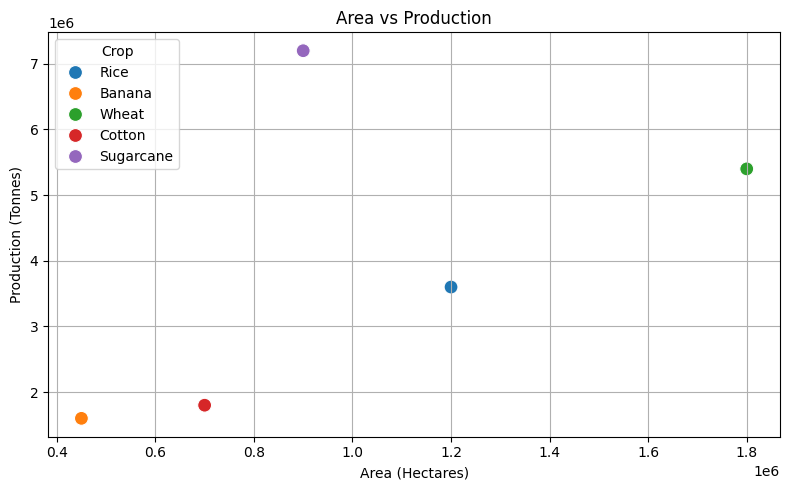

In [15]:
# Analyze relationship between cultivated area and production
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Area_Hectares',
    y='Production_Tonnes',
    hue='Crop',
    s=100
)

plt.title('Area vs Production')
plt.xlabel('Area (Hectares)')
plt.ylabel('Production (Tonnes)')
plt.grid(True)
plt.tight_layout()
plt.show()

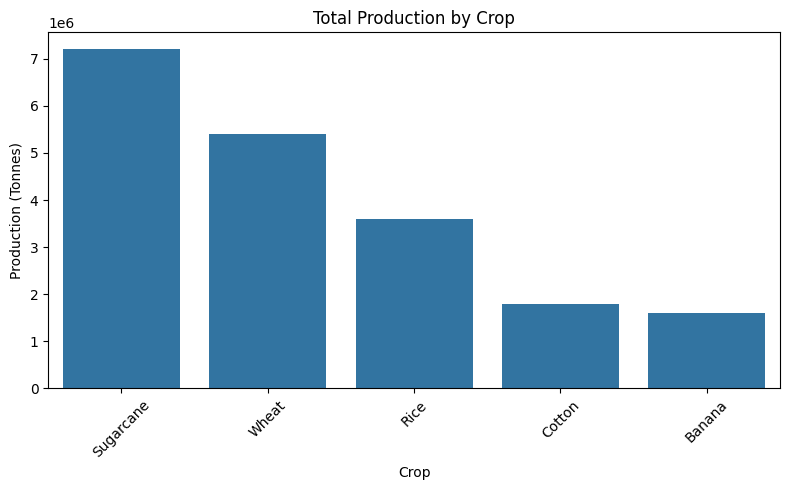

In [16]:
# Crop-wise production visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    x=crop_production.index,
    y=crop_production.values
)

plt.title('Total Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

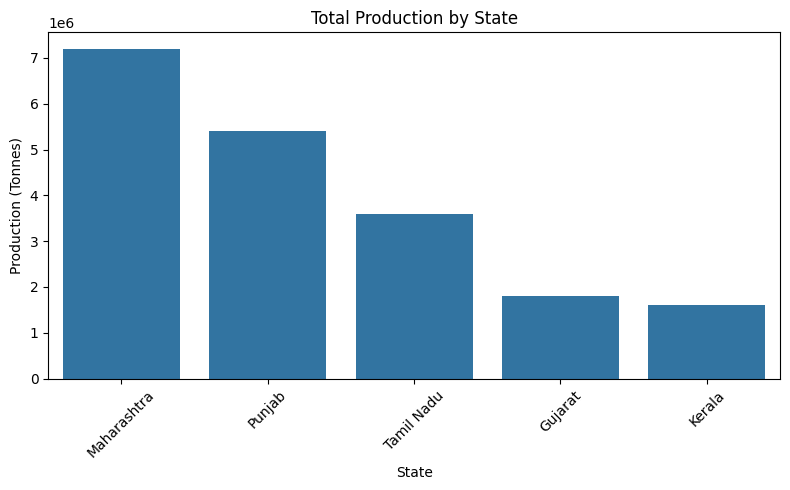

In [17]:
# State-wise production visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    x=state_production.index,
    y=state_production.values
)

plt.title('Total Production by State')
plt.xlabel('State')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

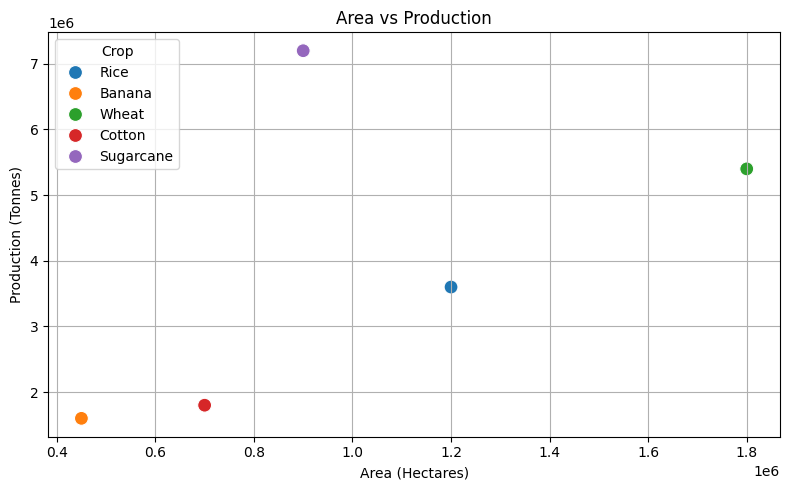

In [18]:
# Area vs Production visualization

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Area_Hectares',
    y='Production_Tonnes',
    hue='Crop',
    s=100
)

plt.title('Area vs Production')
plt.xlabel('Area (Hectares)')
plt.ylabel('Production (Tonnes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Calculate production per hectare

df['Production_Per_Hectare'] = (
    df['Production_Tonnes'] / df['Area_Hectares']
)

print("Production per Hectare:")
print(df[['State', 'Crop', 'Production_Per_Hectare']])

Production per Hectare:
         State       Crop  Production_Per_Hectare
0   Tamil Nadu       Rice                3.000000
1       Kerala     Banana                3.555556
2       Punjab      Wheat                3.000000
3      Gujarat     Cotton                2.571429
4  Maharashtra  Sugarcane                8.000000


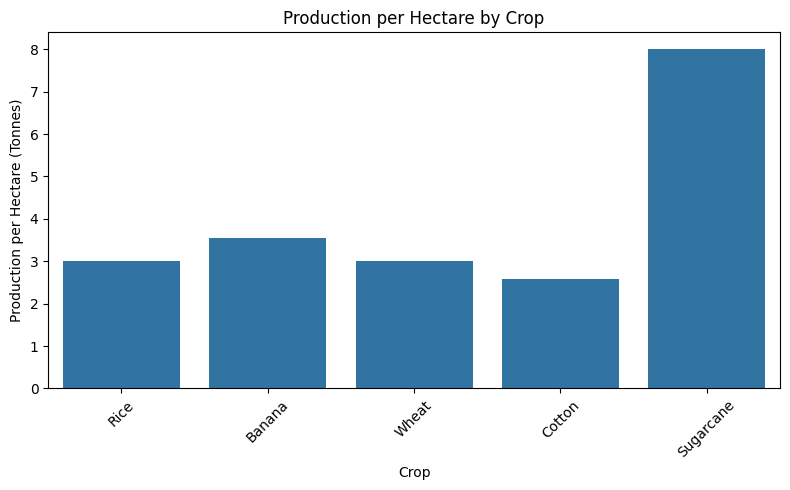

In [20]:
# Production per hectare visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Crop',
    y='Production_Per_Hectare'
)

plt.title('Production per Hectare by Crop')
plt.xlabel('Crop')
plt.ylabel('Production per Hectare (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Identify the highest-producing crop

highest_crop = crop_production.idxmax()
highest_production = crop_production.max()

print("Highest Producing Crop:", highest_crop)
print("Production:", highest_production, "tonnes")

Highest Producing Crop: Sugarcane
Production: 7200000 tonnes
